## 4. Modeling and Evaluation

This notebook will train four models.

* Naive Forecast(baseline model)
* VAR (Vector Autoregressive)
* Prophet
* LSTM (Long Short-Term Memory)

And compare the performance of each model for forecasting traffic flow on the I-405 freeway LA segment. The performance of these models is assessed based on RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error), with lower values indicating better performance.

In [ ]:
# # run this cell for google colab only
# !pip install sktime

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller

from sktime.forecasting.var import VAR
from sktime.utils.plotting import plot_series

from prophet import Prophet

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import timeseries_dataset_from_array

In [ ]:
df = pd.read_csv('../data/cleared-combine-21-23.csv', index_col='time', parse_dates=True)
df.index.freq = 'h'
df.head()

,isholiday,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826,...,767351,717819,717823,767367,717825,717827,771808,771767,772011,772024
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,1,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,1,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,1,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,1,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,1,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0


In [ ]:
station = pd.read_csv('../data/station_cleaned.csv')
station.head()

,city,id,ca_pm,abs_pm,length
0,Long Beach,771826,.11,24.058,0.303
1,Long Beach,717696,.6,24.548,0.495
2,Long Beach,718219,1.1,25.048,0.565
3,Long Beach,717701,1.73,25.678,0.675
4,Long Beach,717703,2.45,26.398,0.505


In [ ]:
station['city'].value_counts()

city
Los Angeles      37
Long Beach       20
Carson           11
other            10
Inglewood         8
Torrance          4
Hawthorne         4
Culver City       4
Signal Hill       3
Lawndale          3
Redondo Beach     1
Name: count, dtype: int64

VAR model requires stationary data. <br>Use station number in each city as weigh to get sample stations for VAR modeling.

In [ ]:
flow = df.iloc[:, 9:].copy()

In [ ]:
# convert station id to str
station['id'] = station['id'].astype(str)
flow.columns = flow.columns.astype(str)

# map city weights to station ID
city_weights = station['city'].value_counts()
station_city_weights = station.set_index('id')['city'].map(city_weights)
weight = station_city_weights[flow.columns]

In [ ]:
sample_stations = flow.sample(n = 10, axis=1, weights = weight, random_state = 42)
sample_stations

,771969,771767,716739,717801,771877,717706,717823,775137,716738,717696
time,,,,,,,,,,
2021-01-01 00:00:00,1161.0,3291.0,2039.0,2559.0,1224.0,1190.0,1072.0,1612.0,1589.0,846.0
2021-01-01 01:00:00,1266.0,3487.0,2146.0,2968.0,1201.0,1144.0,1151.0,1727.0,1754.0,880.0
2021-01-01 02:00:00,857.0,2938.0,1649.0,2504.0,942.0,722.0,808.0,1080.0,1154.0,609.0
2021-01-01 03:00:00,584.0,2506.0,1323.0,2128.0,847.0,558.0,541.0,668.0,720.0,403.0
2021-01-01 04:00:00,614.0,2557.0,1228.0,2105.0,888.0,582.0,503.0,612.0,597.0,473.0
...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,6283.0,5658.0,6240.0,4499.0,1261.0,4600.0,3561.0,5736.0,7594.0,5138.0
2023-12-31 20:00:00,6223.0,5097.0,5628.0,3865.0,1205.0,3788.0,3011.0,5015.0,7135.0,5011.0
2023-12-31 21:00:00,6054.0,4128.0,4981.0,3399.0,1053.0,3273.0,2546.0,4434.0,6401.0,4732.0


In [ ]:
def df_adfuller(df, max_diff=2):
    '''
    Apply the Augmented Dickey-Fuller test on each column of the input DataFrame.
    If the p-value > 0.05, apply .diff() and calculate p-values for the differenced data.

    Args:
        df: DataFrame
        max_diff: Maximum number of differencing to apply (default to 2 times)

    Returns:
        DataFrame: Stores original p-values and differencing p-values for each station.
    '''
    results_df = []

    for column in df.columns:
        p_values = []
        row = df[column]

        origin_p_value = adfuller(row)[1]
        p_values.append(origin_p_value)

        diff_count = 0
        while origin_p_value > 0.05 and diff_count < max_diff:
            diff_count += 1
            row = row.diff().dropna()
            current_p_value = adfuller(row)[1]
            p_values.append(current_p_value)
            origin_p_value = current_p_value

        # if the station data becomes stationary, fill in N/A
        if len(p_values) < max_diff + 1:
            p_values.extend(['NA'] * (max_diff + 1 - len(p_values)))

        results_df.append([column] + p_values)

    outcome = pd.DataFrame(results_df, columns=['station', 'p-value'] + [f'{i+1}_diff_p_value' for i in range(max_diff)])

    return outcome

### 4.1 Baseline

In [ ]:
# Set up baseline model. Use the last value from the training set, continued into the future.

In [ ]:
train, test = train_test_split(sample_stations, test_size = 0.25, shuffle = False)

In [ ]:
base = np.tile(train.iloc[-1].values, (len(test), 1))
baseline = pd.DataFrame(data = base, index = test.index, columns=test.columns)
baseline.head()

,771969,771767,716739,717801,771877,717706,717823,775137,716738,717696
time,,,,,,,,,,
2023-04-02 06:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 07:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 08:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 09:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0
2023-04-02 10:00:00,1839.0,1931.0,1208.0,1271.0,143.0,1772.0,799.0,1309.0,1325.0,1341.0


In [ ]:
print(f'RMSE: {root_mean_squared_error(test, baseline)}')
print(f'MAE: {mean_absolute_error(test, baseline)}')

RMSE: 3966.2666251002984
MAE: 3428.6310725916983


### 4.2 VAR

In [ ]:
# monthly
sample_stations_m = sample_stations.resample('ME').mean()

In [ ]:
df_adfuller(sample_stations_m)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,0.386135,0.000078,NA
1,771767,0.655694,0.001312,NA
2,716739,0.045872,NA,NA
3,717801,0.017054,NA,NA
4,771877,0.474578,0.000036,NA
5,717706,0.000002,NA,NA
6,717823,0.006294,NA,NA
7,775137,0.002829,NA,NA
8,716738,0.012575,NA,NA
9,717696,0.874586,0.006694,NA


In [ ]:
var_m = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']].resample('ME').mean(), sample_stations_m, how='inner', on='time')

In [ ]:
var_m['771969_diff_1'] = sample_stations_m['771969'].diff()
var_m['771767_diff_1'] = sample_stations_m['771767'].diff()
var_m['771877_diff_1'] = sample_stations_m['771877'].diff()
var_m['717696_diff_1'] = sample_stations_m['717696'].diff()
var_m = var_m.drop(columns=['771969', '771767', '771877', '717696'])
var_m.dropna(inplace=True)

In [ ]:
X = var_m.iloc[:,:4]
y = var_m.iloc[:,4:]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [ ]:
model = VAR(maxlags=12, verbose=True)

In [ ]:
model.fit(y_train, X = X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


VAR(maxlags=12, verbose=True)

In [ ]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [ ]:
preds = model.predict(y_test.index)

In [ ]:
forecast_var_m = pd.DataFrame(data = preds, columns = y.columns, index = y_test.index)

In [ ]:
y.columns

Index(['716739', '717801', '717706', '717823', '775137', '716738',
       '771969_diff_1', '771767_diff_1', '771877_diff_1', '717696_diff_1'],
      dtype='object')

In [ ]:
# undifference the first-differenced columns
forecast_var_m['771969'] = sample_stations_m['771969'].iloc[-len(y_test)-1] + forecast_var_m['771969_diff_1'].cumsum()
forecast_var_m['771767'] = sample_stations_m['771767'].iloc[-len(y_test)-1] + forecast_var_m['771767_diff_1'].cumsum()
forecast_var_m['771877'] = sample_stations_m['771877'].iloc[-len(y_test)-1] + forecast_var_m['771877_diff_1'].cumsum()
forecast_var_m['717696'] = sample_stations_m['717696'].iloc[-len(y_test)-1] + forecast_var_m['717696_diff_1'].cumsum()
forecast_var_m.drop(columns=['771969_diff_1', '771767_diff_1', '771877_diff_1', '717696_diff_1'], inplace=True)

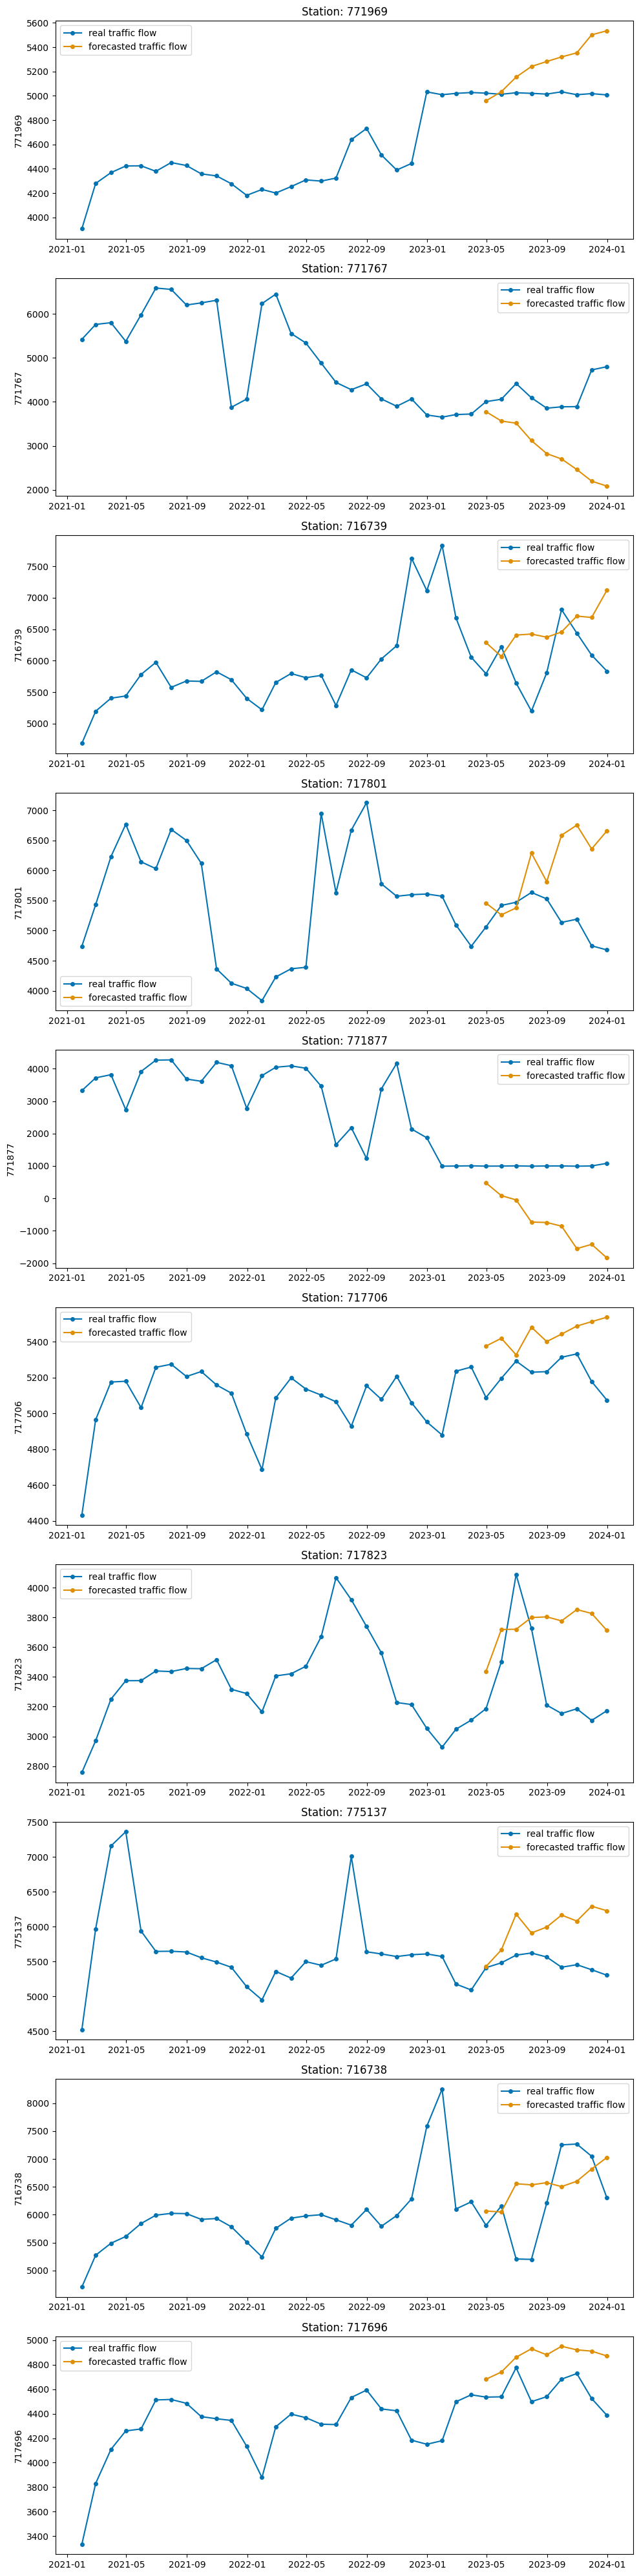

In [ ]:
n_stations = len(sample_stations_m.columns)

fig, axes = plt.subplots(n_stations, 1, figsize=(10, 4 * n_stations))
for i, station in enumerate(sample_stations_m.columns):
    plot_series(sample_stations_m[station],
                forecast_var_m[station],
                labels=['real traffic flow', 'forecasted traffic flow'],
                ax=axes[i])
    axes[i].set_title(f'Station: {station}')

plt.tight_layout()
plt.savefig('../images/var_monthly.png')

In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test, preds)}')
print(f'MAE: {mean_absolute_error(y_test, preds)}')

RMSE: 510.43912889885803
MAE: 424.7998997672911


In [ ]:
# weekly
sample_stations_w = sample_stations.resample('W').mean()
df_adfuller(sample_stations_w)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,7.130871e-01,0.000021,NA
1,771767,5.943516e-02,0.000001,NA
2,716739,2.112393e-03,NA,NA
3,717801,1.461384e-01,0.0,NA
4,771877,3.233503e-01,0.0,NA
5,717706,1.249257e-13,NA,NA
6,717823,1.226881e-03,NA,NA
7,775137,4.440234e-03,NA,NA
8,716738,1.204898e-04,NA,NA
9,717696,1.022143e-04,NA,NA


In [ ]:
var_w = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']].resample('W').mean(), sample_stations_w, how='inner', on='time')
var_w['771969_diff_1'] = sample_stations_w['771969'].diff()
var_w['771767_diff_1'] = sample_stations_w['771767'].diff()
var_w['717801_diff_1'] = sample_stations_w['717801'].diff()
var_w['771877_diff_1'] = sample_stations_w['771877'].diff()
var_w = var_w.drop(columns=['771969', '771767', '717801', '771877'])
var_w.dropna(inplace=True)
X = var_w.iloc[:,:4]
y = var_w.iloc[:,4:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [ ]:
model = VAR(maxlags=52, verbose=True)
model.fit(y_train, X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


VAR(maxlags=52, verbose=True)

In [ ]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [ ]:
preds_w = model.predict(y_test.index)
forecast_var_w = pd.DataFrame(data = preds_w, columns = y.columns, index = y_test.index)

In [ ]:
# undifference the first-differenced columns
forecast_var_w['771969'] = sample_stations_w['771969'].iloc[-len(y_test)-1] + forecast_var_w['771969_diff_1'].cumsum()
forecast_var_w['771767'] = sample_stations_w['771767'].iloc[-len(y_test)-1] + forecast_var_w['771767_diff_1'].cumsum()
forecast_var_w['717801'] = sample_stations_w['717801'].iloc[-len(y_test)-1] + forecast_var_w['717801_diff_1'].cumsum()
forecast_var_w['771877'] = sample_stations_w['771877'].iloc[-len(y_test)-1] + forecast_var_w['771877_diff_1'].cumsum()
forecast_var_w.drop(columns=['771969_diff_1', '771767_diff_1', '717801_diff_1', '771877_diff_1'], inplace=True)

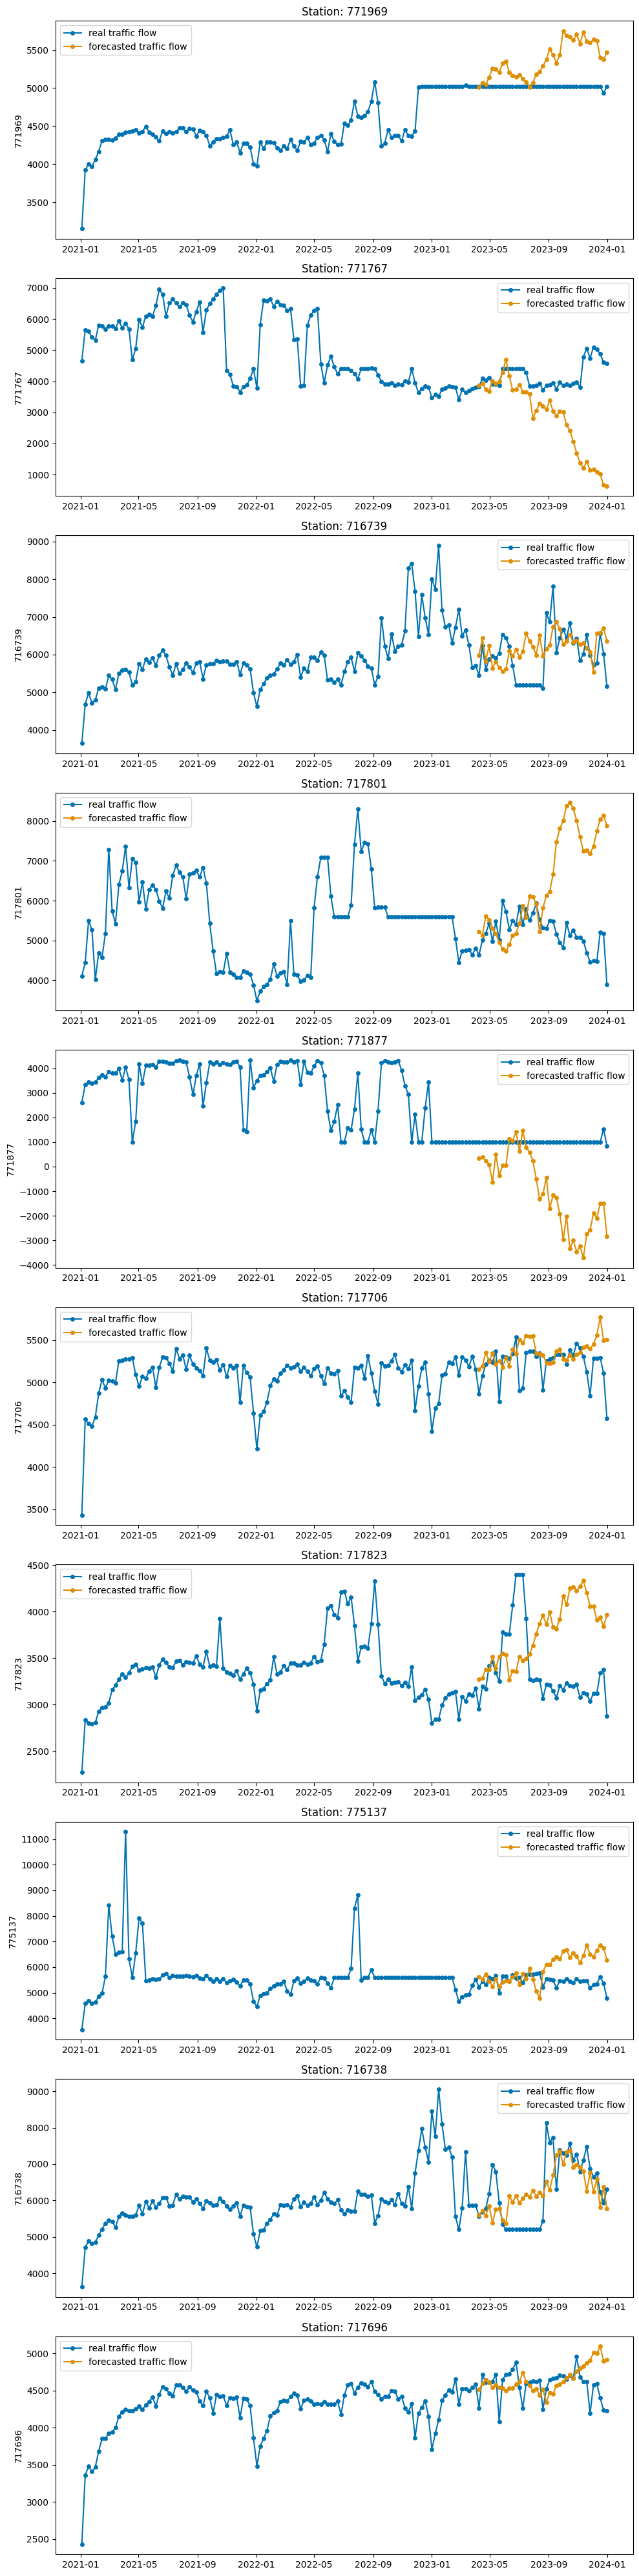

In [ ]:
n_stations = len(sample_stations_w.columns)

fig, axes = plt.subplots(n_stations, 1, figsize=(10, 4 * n_stations))
for i, station in enumerate(sample_stations_w.columns):
    plot_series(sample_stations_w[station],
                forecast_var_w[station],
                labels=['real traffic flow', 'forecasted traffic flow'],
                ax=axes[i])
    axes[i].set_title(f'Station: {station}')

plt.tight_layout()
plt.savefig('../images/var_weekly.png')

In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test, preds_w)}')
print(f'MAE: {mean_absolute_error(y_test, preds_w)}')

RMSE: 518.112955232946
MAE: 421.54034890113115


In [ ]:
# daily
sample_stations_d = sample_stations.resample('d').mean()
df_adfuller(sample_stations_d)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,0.463654,0.0,NA
1,771767,0.077679,0.0,NA
2,716739,0.010292,NA,NA
3,717801,0.090348,0.0,NA
4,771877,0.205028,0.0,NA
5,717706,0.000013,NA,NA
6,717823,0.011268,NA,NA
7,775137,0.000142,NA,NA
8,716738,0.007543,NA,NA
9,717696,0.001262,NA,NA


In [ ]:
var_d = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']].resample('d').mean(), sample_stations_d, how='inner', on='time')
var_d['771969_diff_1'] = sample_stations_d['771969'].diff()
var_d['771767_diff_1'] = sample_stations_d['771767'].diff()
var_d['717801_diff_1'] = sample_stations_d['717801'].diff()
var_d['771877_diff_1'] = sample_stations_d['771877'].diff()
var_d = var_d.drop(columns=['771969', '771767', '717801', '771877'])
var_d.dropna(inplace=True)
X = var_d.iloc[:,:4]
y = var_d.iloc[:,4:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [ ]:
model = VAR(maxlags=30, verbose=True)
model.fit(y_train, X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


VAR(maxlags=30, verbose=True)

In [ ]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [ ]:
preds_d = model.predict(y_test.index)
forecast_var_d = pd.DataFrame(data = preds_d, columns = y.columns, index = y_test.index)

In [ ]:
# undifference the first-differenced columns
forecast_var_d['771969'] = sample_stations_d['771969'].iloc[-len(y_test)-1] + forecast_var_d['771969_diff_1'].cumsum()
forecast_var_d['771767'] = sample_stations_d['771767'].iloc[-len(y_test)-1] + forecast_var_d['771767_diff_1'].cumsum()
forecast_var_d['717801'] = sample_stations_d['717801'].iloc[-len(y_test)-1] + forecast_var_d['717801_diff_1'].cumsum()
forecast_var_d['771877'] = sample_stations_d['771877'].iloc[-len(y_test)-1] + forecast_var_d['771877_diff_1'].cumsum()
forecast_var_d.drop(columns=['771969_diff_1', '771767_diff_1', '717801_diff_1', '771877_diff_1'], inplace=True)

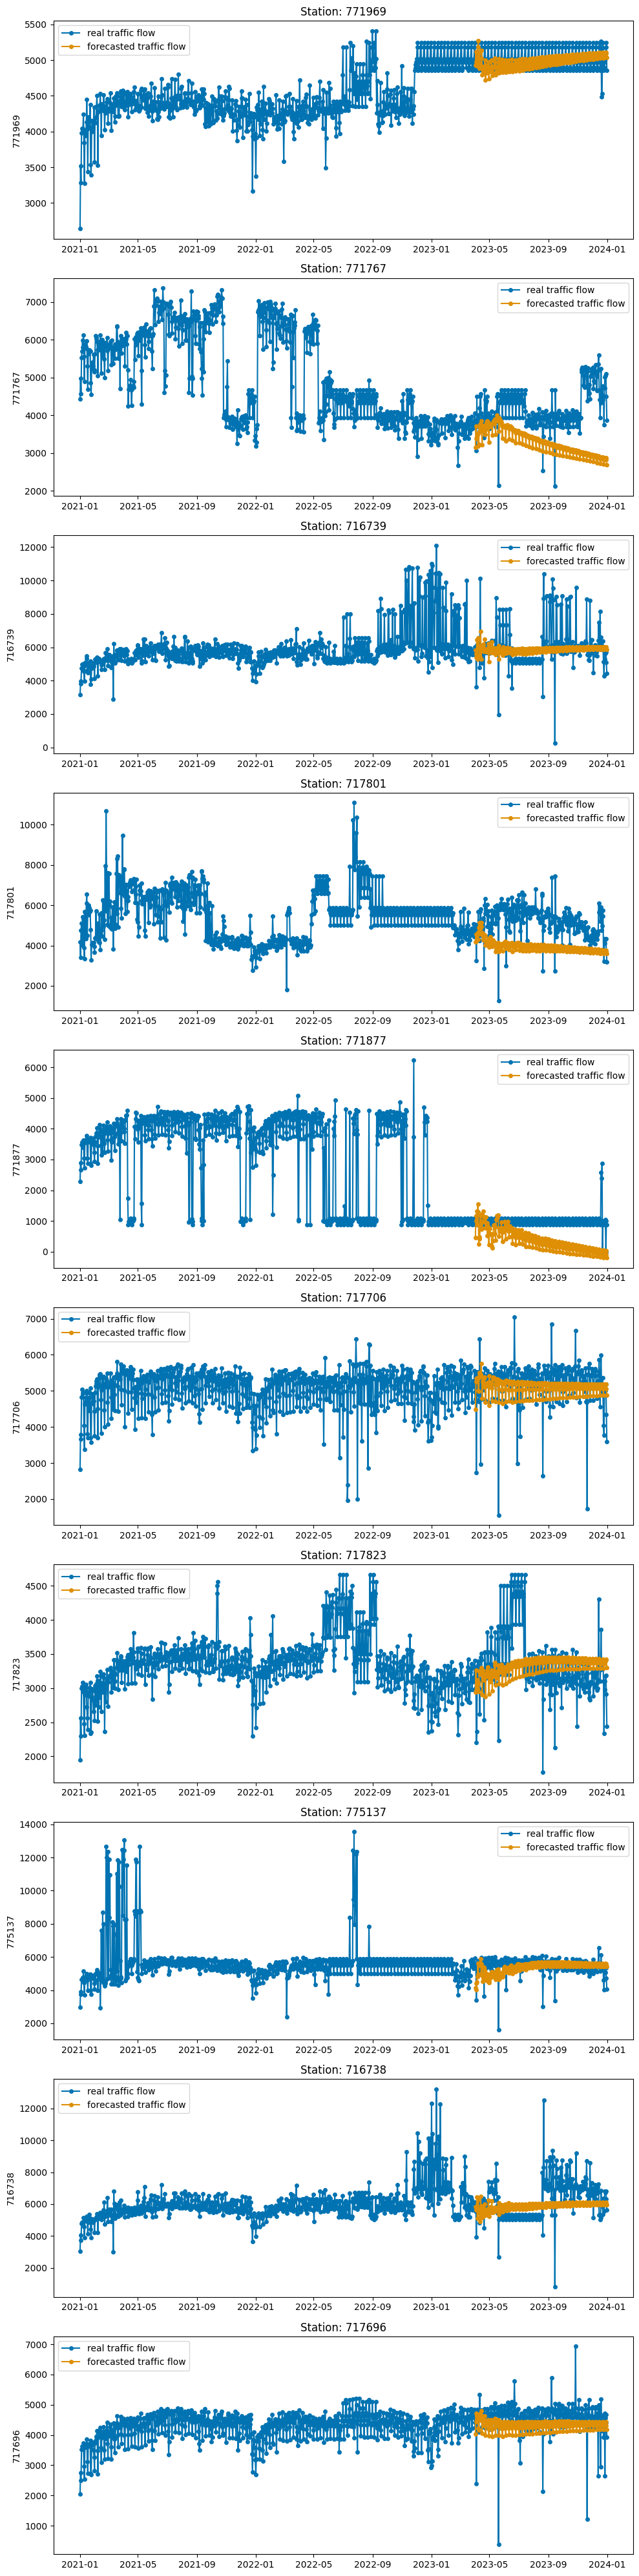

In [ ]:
n_stations = len(sample_stations_d.columns)

fig, axes = plt.subplots(n_stations, 1, figsize=(10, 4 * n_stations))
for i, station in enumerate(sample_stations_d.columns):
    plot_series(sample_stations_d[station],
                forecast_var_d[station],
                labels=['real traffic flow', 'forecasted traffic flow'],
                ax=axes[i])
    axes[i].set_title(f'Station: {station}')

plt.tight_layout()
plt.savefig('../images/var_daily.png')

In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test, preds_d)}')
print(f'MAE: {mean_absolute_error(y_test, preds_d)}')

RMSE: 628.5647717557681
MAE: 410.7332548461548


In [ ]:
# hourly
df_adfuller(sample_stations)

,station,p-value,1_diff_p_value,2_diff_p_value
0,771969,8.108330e-11,NA,NA
1,771767,4.105735e-06,NA,NA
2,716739,4.184550e-25,NA,NA
3,717801,1.831673e-12,NA,NA
4,771877,3.449745e-08,NA,NA
5,717706,0.000000e+00,NA,NA
6,717823,1.243041e-16,NA,NA
7,775137,1.041955e-21,NA,NA
8,716738,1.669286e-18,NA,NA
9,717696,1.354000e-28,NA,NA


In [ ]:
var_h = pd.merge(df[['isholiday', 'temp', 'prcp', 'coco']], sample_stations, how='inner', on='time')
X = var_h.iloc[:,:4]
y = var_h.iloc[:,4:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

In [ ]:
model = VAR(maxlags=24, verbose=True)
model.fit(y_train, X_train)

/opt/anaconda3/envs/sktimeenv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


VAR(maxlags=24, verbose=True)

In [ ]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [ ]:
preds_h = model.predict(y_test.index)
forecast_var_h = pd.DataFrame(data = preds_h, columns = y.columns, index = y_test.index)

In [ ]:
# n_stations = len(sample_stations.columns)

# fig, axes = plt.subplots(n_stations, 1, figsize=(10, 4 * n_stations))
# for i, station in enumerate(sample_stations.columns):
#     plot_series(sample_stations[station],
#                 forecast_var_h[station],
#                 labels=['real traffic flow', 'forecasted traffic flow'],
#                 ax=axes[i])
#     axes[i].set_title(f'Station: {station}')

# plt.tight_layout()
# plt.savefig('../images/var_hourly.png')

In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test, preds_h)}')
print(f'MAE: {mean_absolute_error(y_test, preds_h)}')

RMSE: 2081.8307673809595
MAE: 1772.0427094701051


### 4.3 Prophet

In [ ]:
# prepare dataframe for prophet
prophet_df = pd.merge(sample_stations, df[['isholiday', 'temp', 'prcp', 'coco']], left_index=True, right_index=True)
prophet_df = prophet_df.reset_index()
prophet_df.rename(columns={'index': 'ds', '771969': 'y'}, inplace=True)
prophet_df.head()

,ds,y,771767,716739,717801,771877,717706,717823,775137,716738,717696,isholiday,temp,prcp,coco
0,2021-01-01 00:00:00,1161.0,3291.0,2039.0,2559.0,1224.0,1190.0,1072.0,1612.0,1589.0,846.0,1,17.8,0.0,2.0
1,2021-01-01 01:00:00,1266.0,3487.0,2146.0,2968.0,1201.0,1144.0,1151.0,1727.0,1754.0,880.0,1,16.7,0.0,2.0
2,2021-01-01 02:00:00,857.0,2938.0,1649.0,2504.0,942.0,722.0,808.0,1080.0,1154.0,609.0,1,16.1,0.0,2.0
3,2021-01-01 03:00:00,584.0,2506.0,1323.0,2128.0,847.0,558.0,541.0,668.0,720.0,403.0,1,16.1,0.0,2.0
4,2021-01-01 04:00:00,614.0,2557.0,1228.0,2105.0,888.0,582.0,503.0,612.0,597.0,473.0,1,15.0,0.0,1.0


In [ ]:
# monthly
prophet_df_m = prophet_df.set_index('ds').copy()
prophet_df_m = prophet_df_m.resample('ME').mean()
prophet_df_m.reset_index(inplace=True)

In [ ]:
train, test = train_test_split(prophet_df_m, test_size = 0.25, shuffle = False)

In [ ]:
model = Prophet()
# add other columns as regressors
for i in prophet_df_m.iloc[:,2:].columns:
    model.add_regressor(i)

In [ ]:
model.fit(train)

13:36:37 - cmdstanpy - INFO - Chain [1] start processing
13:36:39 - cmdstanpy - INFO - Chain [1] done processing


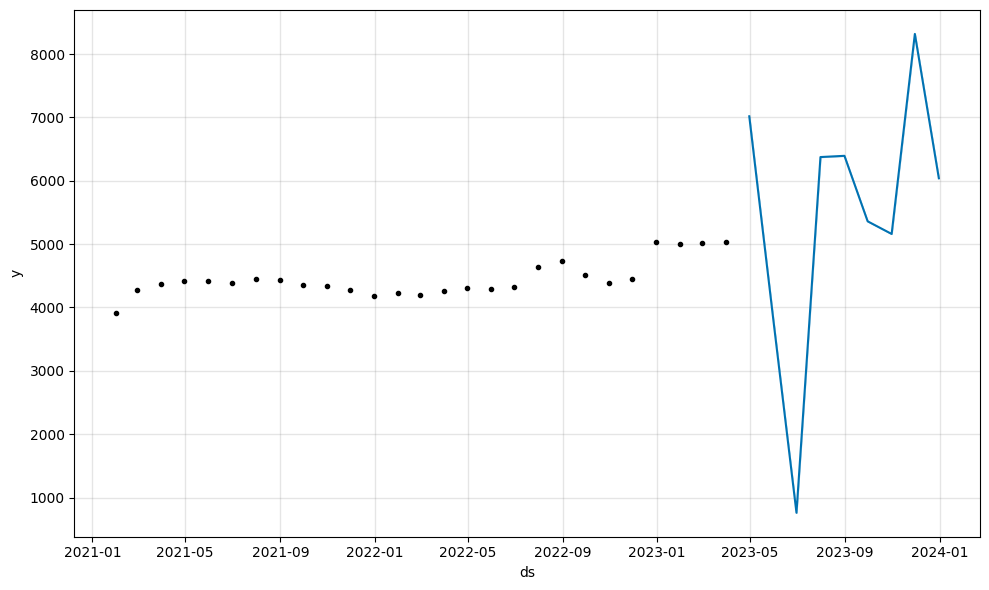

In [ ]:
forecast_m = model.predict(test.drop(columns=['y']))
fig = model.plot(forecast_m);

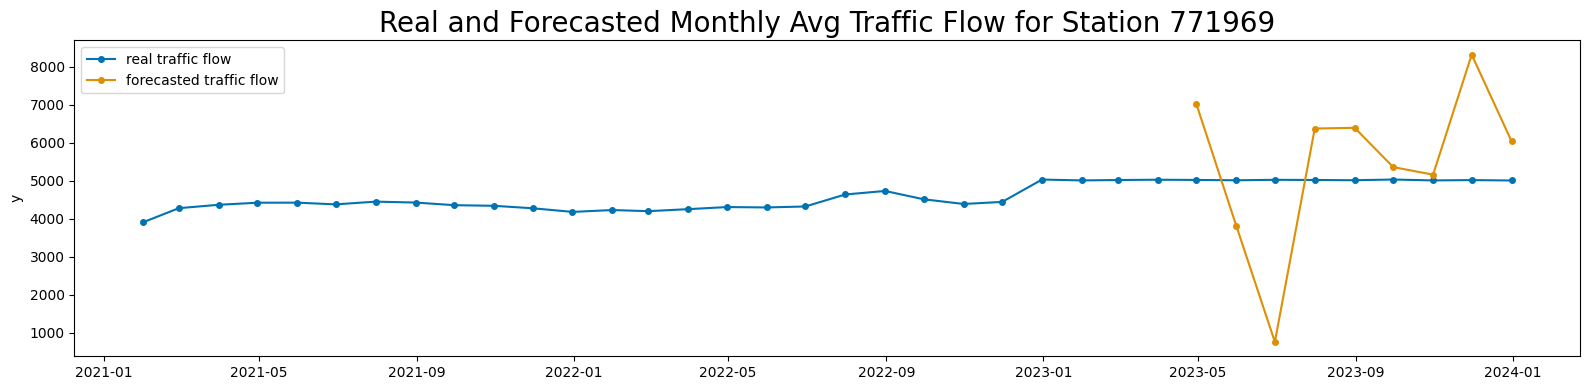

In [ ]:
plot_series(prophet_df_m.set_index('ds')['y'],
            forecast_m.set_index('ds')['yhat'],
            labels=['real traffic flow', 'forecasted traffic flow'])

plt.title('Real and Forecasted Monthly Avg Traffic Flow for Station 771969', size=20)
plt.tight_layout()
plt.savefig('../images/prophet-monthly.png');

In [ ]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_m['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_m['yhat'])}")

RMSE: 2092.8735590465867
MAE: 1666.747484301731


In [ ]:
# weekly

In [ ]:
prophet_df_w = prophet_df.set_index('ds').copy()
prophet_df_w = prophet_df_w.resample('W').mean()
prophet_df_w.reset_index(inplace=True)
train, test = train_test_split(prophet_df_w, test_size = 0.25, shuffle = False)

In [ ]:
model = Prophet()

# add other columns as regressors
for i in prophet_df_w.iloc[:,2:].columns:
    model.add_regressor(i)

In [ ]:
model.fit(train)

13:40:22 - cmdstanpy - INFO - Chain [1] start processing
13:40:22 - cmdstanpy - INFO - Chain [1] done processing


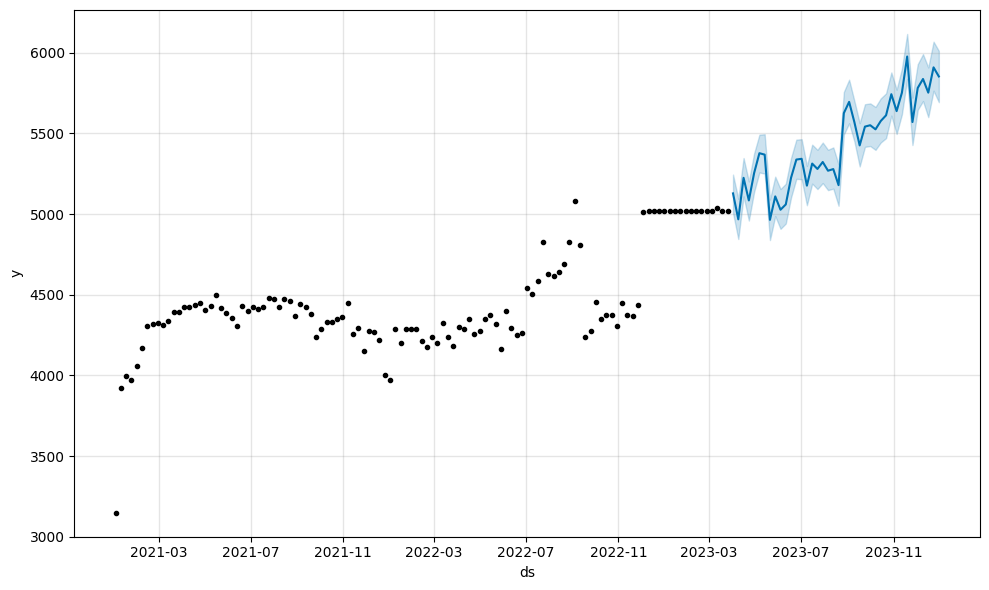

In [ ]:
forecast_w = model.predict(test.drop(columns=['y']))
fig = model.plot(forecast_w);

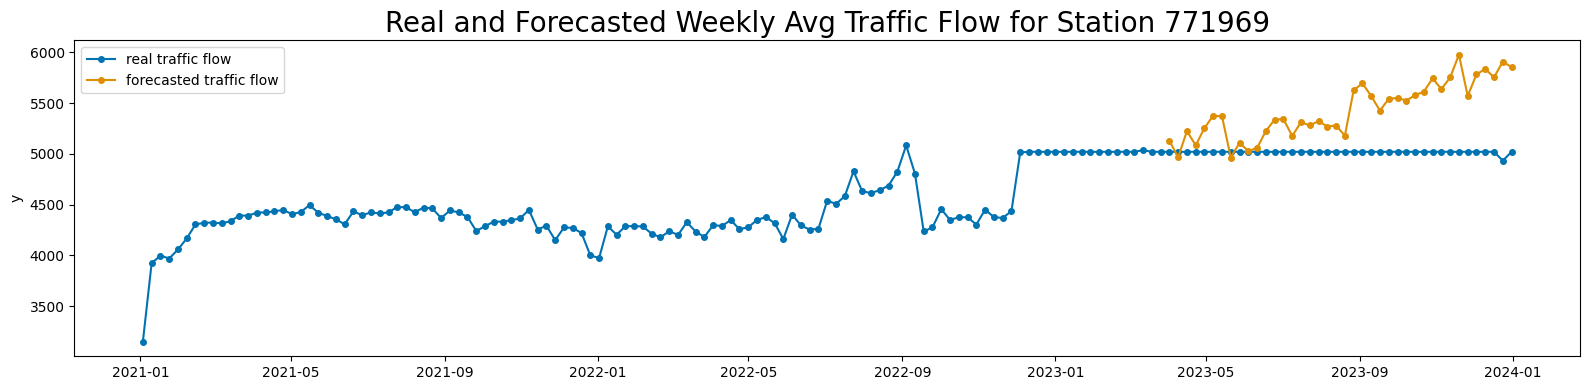

In [ ]:
plot_series(prophet_df_w.set_index('ds')['y'],
            forecast_w.set_index('ds')['yhat'],
            labels=['real traffic flow', 'forecasted traffic flow'])

plt.title('Real and Forecasted Weekly Avg Traffic Flow for Station 771969', size=20)
plt.tight_layout()
plt.savefig('../images/prophet-weekly.png');

In [ ]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_w['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_w['yhat'])}")

RMSE: 497.30507773714055
MAE: 418.0884282209204


In [ ]:
# daily

In [ ]:
prophet_df_d = prophet_df.set_index('ds').copy()
prophet_df_d = prophet_df_d.resample('d').mean()
prophet_df_d.reset_index(inplace=True)
train, test = train_test_split(prophet_df_d, test_size = 0.25, shuffle = False)

In [ ]:
model = Prophet()

# add other columns as regressors
for i in prophet_df_d.iloc[:,2:].columns:
    model.add_regressor(i)

In [ ]:
model.fit(train)

13:43:04 - cmdstanpy - INFO - Chain [1] start processing
13:43:05 - cmdstanpy - INFO - Chain [1] done processing


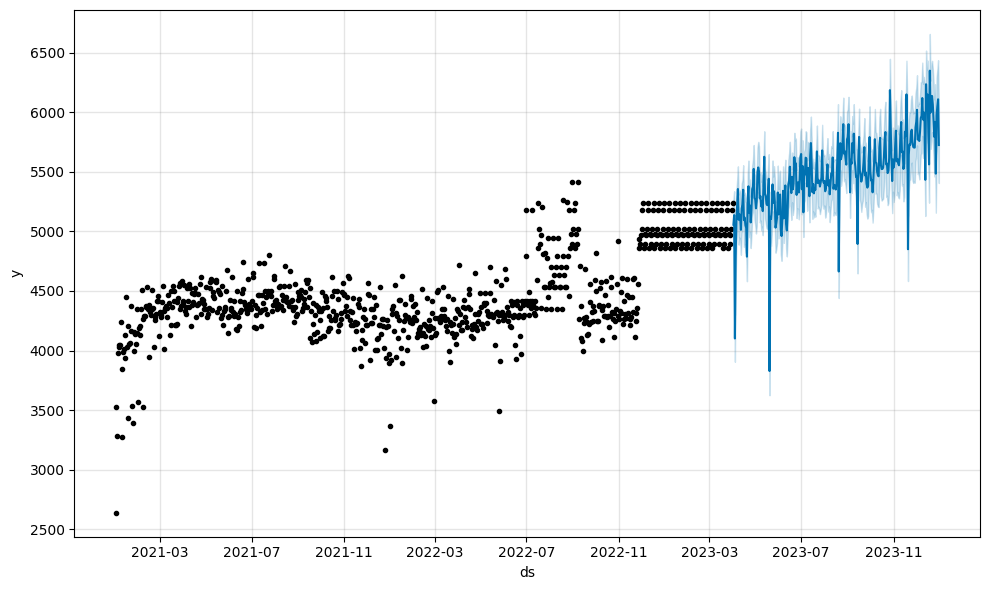

In [ ]:
forecast_d = model.predict(test.drop(columns=['y']))
fig = model.plot(forecast_d);

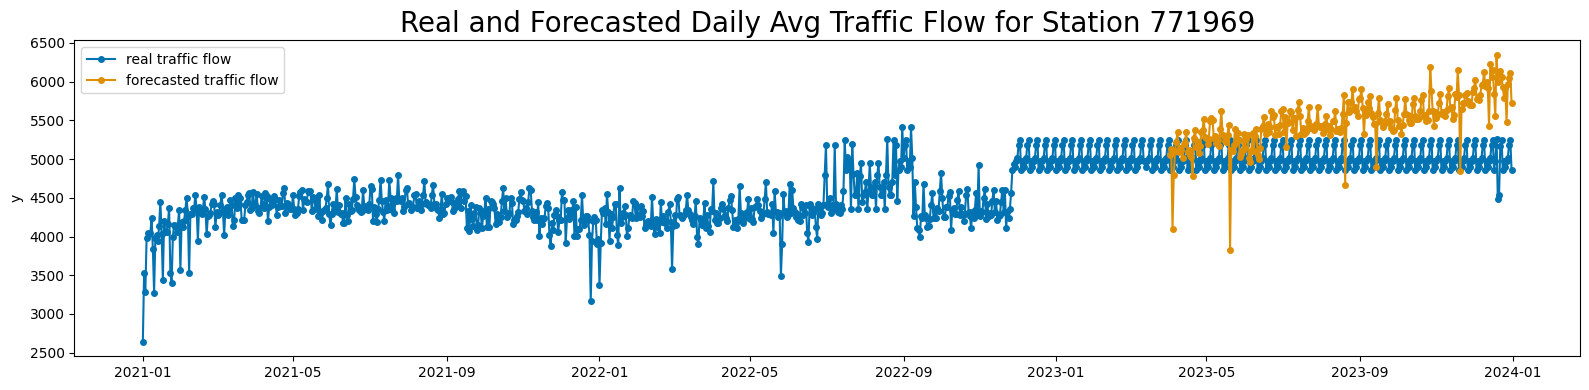

In [ ]:
plot_series(prophet_df_d.set_index('ds')['y'],
            forecast_d.set_index('ds')['yhat'],
            labels=['real traffic flow', 'forecasted traffic flow'])

plt.title('Real and Forecasted Daily Avg Traffic Flow for Station 771969', size=20)
plt.tight_layout()
plt.savefig('../images/prophet-daily.png');

In [ ]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_d['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_d['yhat'])}")

RMSE: 564.8785924042244
MAE: 499.31969312617485


In [ ]:
# hourly

In [ ]:
train, test = train_test_split(prophet_df, test_size = 0.25, shuffle = False)

In [ ]:
model = Prophet()
for i in prophet_df.iloc[:,2:].columns:
    model.add_regressor(i)

In [ ]:
model.fit(train)

13:45:41 - cmdstanpy - INFO - Chain [1] start processing
13:45:48 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
forecast_h = model.predict(test.drop(columns=['y']))

In [ ]:
# hourly plots are unreadable for the following two cells

In [ ]:
# fig = model.plot(forecast_h)

In [ ]:
# plot_series(prophet_df.set_index('ds')['y'],
#             forecast_h.set_index('ds')['yhat'],
#             labels=['real traffic flow', 'forecasted traffic flow'])

# plt.title('Real and Forecasted Daily Avg Traffic Flow for Station 771969', size=20)
# plt.tight_layout()
# plt.savefig('../images/prophet-daily.png');

In [ ]:
print(f"RMSE: {root_mean_squared_error(test['y'], forecast_h['yhat'])}")
print(f"MAE: {mean_absolute_error(test['y'], forecast_h['yhat'])}")

RMSE: 601.0359153874049
MAE: 432.0534049317946


In [ ]:
forecast_h

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,716738,716738_lower,716738_upper,716739,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-04-02 06:00:00,4907.506036,3191.050345,5042.555856,4907.506036,4907.506036,-450.162402,-450.162402,-450.162402,251.158327,...,209.147933,209.147933,209.147933,121.217998,121.217998,121.217998,0.0,0.0,0.0,4094.519717
1,2023-04-02 07:00:00,4907.559747,3249.243265,4975.593377,4907.559747,4907.559747,-278.286800,-278.286800,-278.286800,159.538498,...,208.387126,208.387126,208.387126,121.328574,121.328574,121.328574,0.0,0.0,0.0,4168.536984
2,2023-04-02 08:00:00,4907.613459,3475.675977,5352.257307,4907.613459,4907.613459,-251.916205,-251.916205,-251.916205,142.892454,...,207.154065,207.154065,207.154065,121.437237,121.437237,121.437237,0.0,0.0,0.0,4429.926662
3,2023-04-02 09:00:00,4907.667171,4556.200883,6362.404073,4907.667171,4907.667171,-26.715994,-26.715994,-26.715994,18.646378,...,205.447969,205.447969,205.447969,121.543981,121.543981,121.543981,0.0,0.0,0.0,5417.976019
4,2023-04-02 10:00:00,4907.720883,5489.352800,7249.857370,4907.720883,4907.720883,137.458461,137.458461,137.458461,-87.688554,...,203.269953,203.269953,203.269953,121.648799,121.648799,121.648799,0.0,0.0,0.0,6343.108887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6565,2023-12-31 19:00:00,5260.123917,5680.607085,7990.148937,4661.373381,5917.422795,189.849598,189.849598,189.849598,-23.634575,...,163.601304,163.601304,163.601304,246.834386,246.834386,246.834386,0.0,0.0,0.0,6819.110109
6566,2023-12-31 20:00:00,5260.177629,5473.654703,7671.804021,4661.249064,5917.479873,136.291620,136.291620,136.291620,17.114942,...,157.204205,157.204205,157.204205,246.883532,246.883532,246.883532,0.0,0.0,0.0,6487.169507
6567,2023-12-31 21:00:00,5260.231341,5020.585806,7275.140721,4661.124747,5917.536950,50.645529,50.645529,50.645529,60.194905,...,150.478313,150.478313,150.478313,246.932196,246.932196,246.932196,0.0,0.0,0.0,6157.558489
6568,2023-12-31 22:00:00,5260.285053,4560.952243,6700.687931,4661.018791,5917.607136,-16.097746,-16.097746,-16.097746,86.495655,...,143.447662,143.447662,143.447662,246.980377,246.980377,246.980377,0.0,0.0,0.0,5577.367485


### 4.4 LSTM

In [3]:
# read data for colab
df = pd.read_csv('/content/cleared-combine-21-23.csv', index_col='time', parse_dates=True)
df.index.freq = 'h'
station = pd.read_csv('/content/station_cleaned.csv')

# # read data from local
# df = pd.read_csv('../data/cleared-combine-21-23.csv', index_col='time', parse_dates=True)
# df.index.freq = 'h'
# station = pd.read_csv('../data/station_cleaned.csv')

flow = df.iloc[:, 9:].copy()
# convert station id to str
station['id'] = station['id'].astype(str)
flow.columns = flow.columns.astype(str)

# map city weights to station ID
city_weights = station['city'].value_counts()
station_city_weights = station.set_index('id')['city'].map(city_weights)
weight = station_city_weights[flow.columns]

sample_stations = flow.sample(n = 10, axis=1, weights = weight, random_state = 42)

In [4]:
lstm_df = pd.merge(sample_stations, df[['isholiday', 'temp', 'prcp', 'coco']], how='inner', on='time')

Monthly resampled data will have only 36 rows.
The current dataset is not large enough to train the LSTM model due to the nature of neural networks, which require large datasets.

In [89]:
# weekly
lstm_df_w = lstm_df.resample('W').mean().copy()
X = lstm_df_w.iloc[:,-4:]
y = lstm_df_w.iloc[:,:-4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle=False)

In [90]:
scx = StandardScaler()
X_train_sc = scx.fit_transform(X_train)
X_test_sc = scx.transform(X_test)

scy = StandardScaler()
y_train_sc = scy.fit_transform(y_train)
y_test_sc = scy.transform(y_test)

In [91]:
seq_len = 7
batch_size = 32
sampling_rate = 1

train_gen = timeseries_dataset_from_array(
    X_train_sc,
    y_train_sc,
    sequence_length = seq_len,
    batch_size = batch_size,
    sampling_rate = sampling_rate)

val_gen = timeseries_dataset_from_array(
    X_test_sc,
    y_test_sc,
    sequence_length = seq_len,
    batch_size = batch_size,
    sampling_rate = sampling_rate)

In [92]:
model = Sequential()
es = EarlyStopping(patience=5)

model.add(Input(shape=(seq_len, X_train.shape[1])))

model.add(BatchNormalization())
model.add(LSTM(32, return_sequences = True, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(len(y_train.columns)))

model.compile(loss = 'mse', optimizer = 'rmsprop', metrics = ['mae'])

history = model.fit(train_gen,
                    validation_data = val_gen,
                    epochs = 50,
                    callbacks=es)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - loss: 1.0815 - mae: 0.7006 - val_loss: 1.4479 - val_mae: 0.9723
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0552 - mae: 0.6916 - val_loss: 1.4402 - val_mae: 0.9729
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0456 - mae: 0.6885 - val_loss: 1.4318 - val_mae: 0.9727
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.0335 - mae: 0.6842 - val_loss: 1.4251 - val_mae: 0.9736
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0250 - mae: 0.6826 - val_loss: 1.4178 - val_mae: 0.9738
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0144 - mae: 0.6806 - val_loss: 1.4101 - val_mae: 0.9739
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9992 - mae: 0.6747 - val_loss: 1.4014 - val_mae: 0.9742
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9884 - mae: 0.6717 - val_loss: 1.3935 - val_mae: 0.9751
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.9727 - mae: 0.6704 -

In [93]:
predictions_scaled = model.predict(val_gen)
predicted_traffic = scy.inverse_transform(predictions_scaled)
true_traffic = scy.inverse_transform(y_test_sc[-len(predictions_scaled):])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


In [94]:
print(f'RMSE: {root_mean_squared_error(true_traffic, predicted_traffic)}')
print(f'MAE: {mean_absolute_error(true_traffic, predicted_traffic)}')

RMSE: 766.6910154406806
MAE: 701.0377165584928


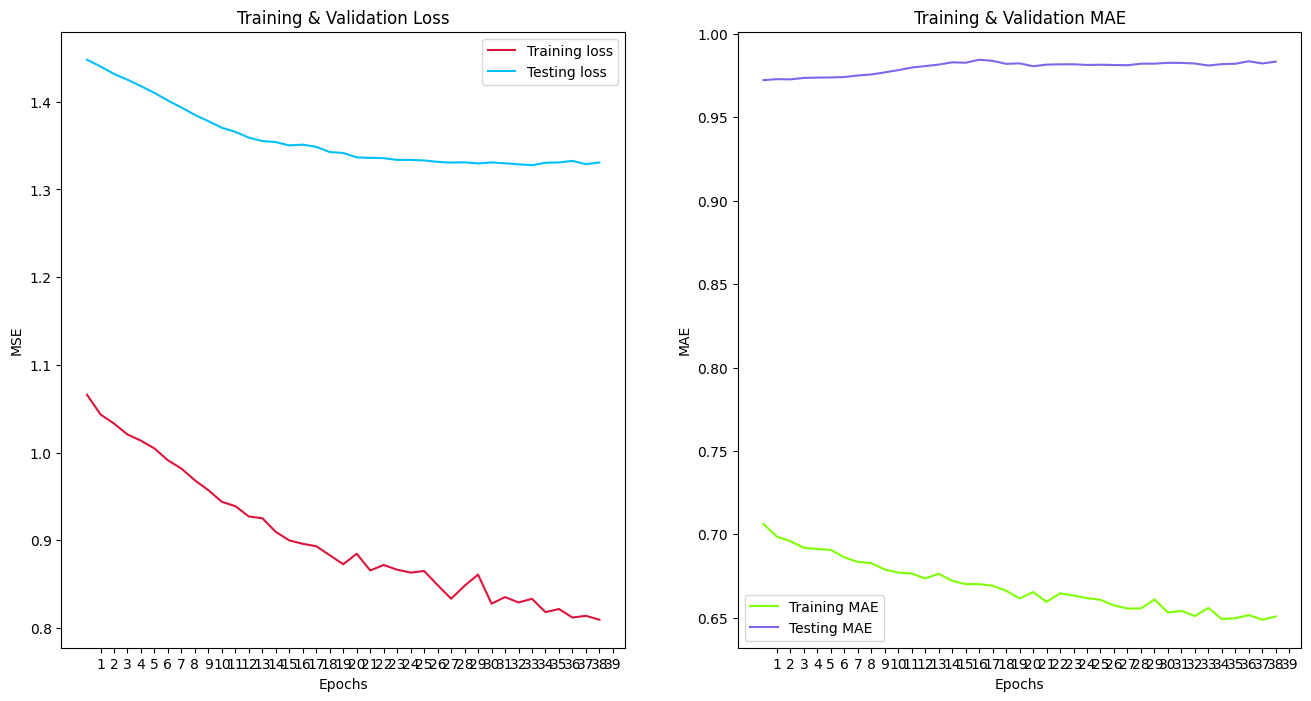

In [95]:
plt.figure(figsize=(16, 8))
# loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', color='crimson')
plt.plot(history.history['val_loss'], label='Testing loss', color='deepskyblue')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.xticks(range(1, len(history.history['loss']) + 1)) # set to int for each epoch
plt.ylabel('MSE')
plt.legend()

# mae
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', color='chartreuse')
plt.plot(history.history['val_mae'], label='Testing MAE', color='mediumslateblue')
plt.title('Training & Validation MAE')
plt.xlabel('Epochs')
plt.xticks(range(1, len(history.history['mae']) + 1))
plt.ylabel('MAE')
plt.legend();

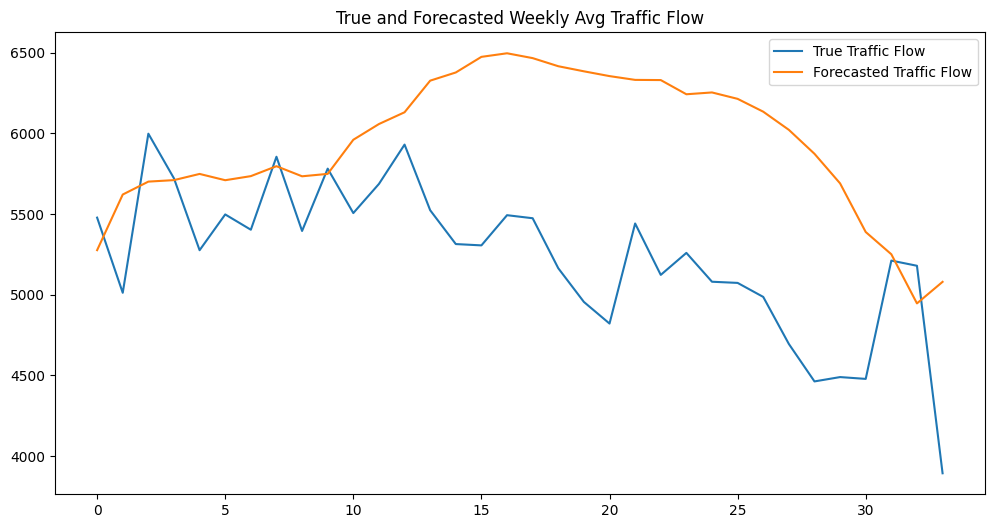

In [96]:
plt.figure(figsize=(12, 6))
plt.plot(true_traffic[:52, 3], label='True Traffic Flow')
plt.plot(predicted_traffic[:52, 3], label='Forecasted Traffic Flow')
plt.legend()
plt.title('True and Forecasted Weekly Avg Traffic Flow')
plt.show()

In [97]:
# daily
lstm_df_d = lstm_df.resample('d').mean().copy()
X = lstm_df_d.iloc[:,-4:]
y = lstm_df_d.iloc[:,:-4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle=False)

In [98]:
scx = StandardScaler()
X_train_sc = scx.fit_transform(X_train)
X_test_sc = scx.transform(X_test)

scy = StandardScaler()
y_train_sc = scy.fit_transform(y_train)
y_test_sc = scy.transform(y_test)

In [99]:
seq_len = 24
batch_size = 8
sampling_rate = 1

train_gen = timeseries_dataset_from_array(
    X_train_sc,
    y_train_sc,
    sequence_length = seq_len,
    batch_size = batch_size,
    sampling_rate = sampling_rate)

val_gen = timeseries_dataset_from_array(
    X_test_sc,
    y_test_sc,
    sequence_length = seq_len,
    batch_size = batch_size,
    sampling_rate = sampling_rate)

In [100]:
model = Sequential()
es = EarlyStopping(patience=5)

model.add(Input(shape=(seq_len, X_train.shape[1])))

model.add(BatchNormalization())
model.add(LSTM(32, return_sequences = True, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(len(y_train.columns)))

model.compile(loss = 'mse', optimizer = 'rmsprop', metrics = ['mae'])

history = model.fit(train_gen,
                    validation_data = val_gen,
                    epochs = 20,
                    callbacks=es)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.0806 - mae: 0.7207 - val_loss: 1.1490 - val_mae: 0.7804
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1661 - mae: 0.7706 - val_loss: 1.0399 - val_mae: 0.7211
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1995 - mae: 0.7820 - val_loss: 1.0465 - val_mae: 0.7070
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.1498 - mae: 0.7557 - val_loss: 1.1124 - val_mae: 0.7341
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1559 - mae: 0.7657 - val_loss: 1.0816 - val_mae: 0.7020
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0931 - mae: 0.7246 - val_loss: 0.9652 - val_mae: 0.6575
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1780 - mae: 0.7515 - val_loss: 0.9912 - val_mae: 0.6688
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1699 - mae: 0.7469 - val_loss: 0.9798 - val_mae: 0.6548
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step 

In [101]:
predictions_scaled = model.predict(val_gen)
predicted_traffic = scy.inverse_transform(predictions_scaled)
true_traffic = scy.inverse_transform(y_test_sc[-len(predictions_scaled):])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [102]:
print(f'RMSE: {root_mean_squared_error(true_traffic, predicted_traffic)}')
print(f'MAE: {mean_absolute_error(true_traffic, predicted_traffic)}')

RMSE: 685.7887438407774
MAE: 511.2483797489478


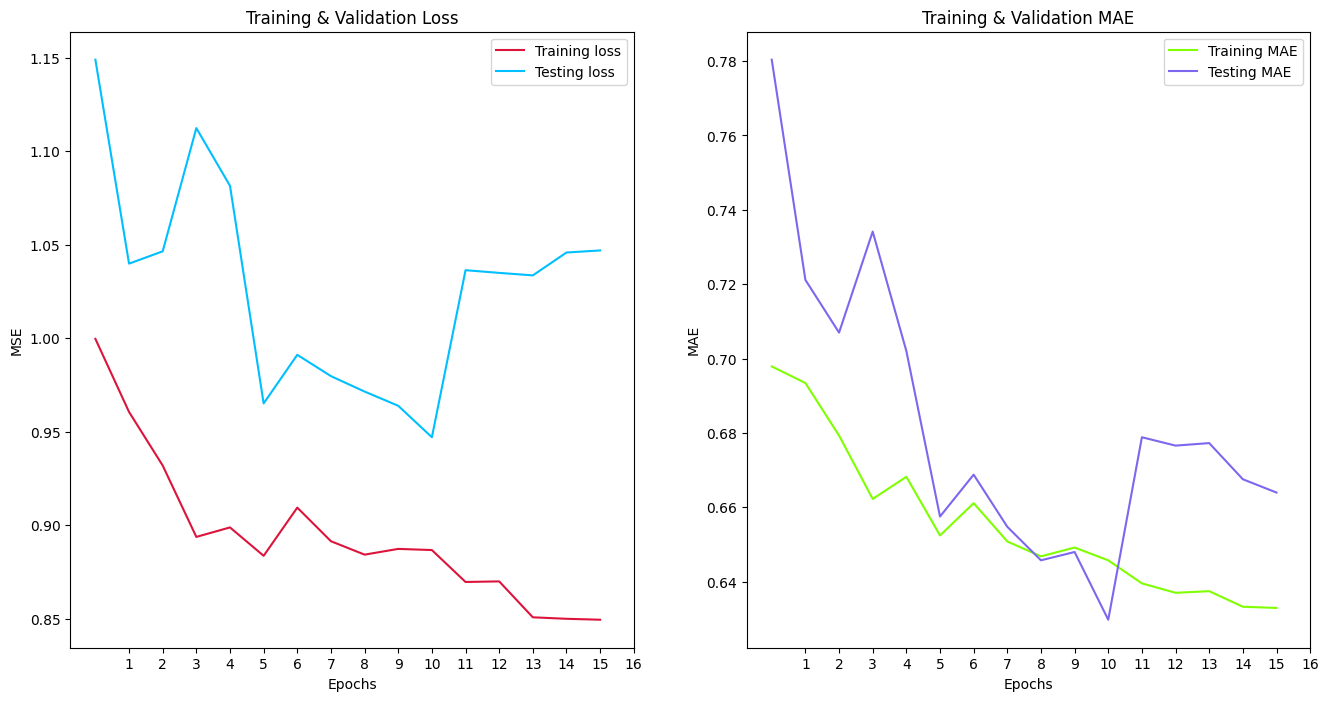

In [103]:
plt.figure(figsize=(16, 8))
# loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', color='crimson')
plt.plot(history.history['val_loss'], label='Testing loss', color='deepskyblue')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.xticks(range(1, len(history.history['loss']) + 1)) # set to int for each epoch
plt.ylabel('MSE')
plt.legend()

# mae
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', color='chartreuse')
plt.plot(history.history['val_mae'], label='Testing MAE', color='mediumslateblue')
plt.title('Training & Validation MAE')
plt.xlabel('Epochs')
plt.xticks(range(1, len(history.history['mae']) + 1))
plt.ylabel('MAE')
plt.legend();

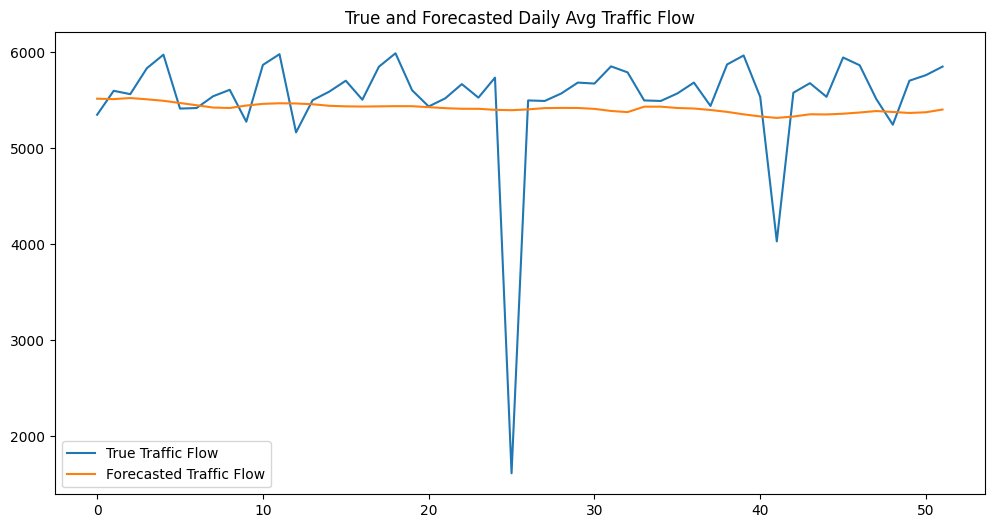

In [104]:
plt.figure(figsize=(12, 6))
plt.plot(true_traffic[:52, 7], label='True Traffic Flow')
plt.plot(predicted_traffic[:52, 7], label='Forecasted Traffic Flow')
plt.legend()
plt.title('True and Forecasted Daily Avg Traffic Flow')
plt.show()

In [ ]:
# hourly

In [105]:
X = lstm_df.iloc[:,-4:]
y = lstm_df.iloc[:,:-4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle=False)

In [106]:
scx = StandardScaler()
X_train_sc = scx.fit_transform(X_train)
X_test_sc = scx.transform(X_test)

scy = StandardScaler()
y_train_sc = scy.fit_transform(y_train)
y_test_sc = scy.transform(y_test)

In [107]:
seq_len = 24
batch_size = 32
sampling_rate = 1

train_gen = timeseries_dataset_from_array(
    X_train_sc,
    y_train_sc,
    sequence_length = seq_len,
    batch_size = batch_size,
    sampling_rate = sampling_rate)

val_gen = timeseries_dataset_from_array(
    X_test_sc,
    y_test_sc,
    sequence_length = seq_len,
    batch_size = batch_size,
    sampling_rate = sampling_rate)

In [108]:
model = Sequential()
es = EarlyStopping(patience=5)

model.add(Input(shape=(seq_len, X_train.shape[1])))

model.add(BatchNormalization())
model.add(LSTM(32, return_sequences = True, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.2))

model.add(LSTM(32, kernel_regularizer=l2(0.01)))
model.add(Dropout(0.2))

model.add(Dense(len(y_train.columns)))

model.compile(loss = 'mse', optimizer = 'rmsprop', metrics = ['mae'])

history = model.fit(train_gen,
                    validation_data = val_gen,
                    epochs = 20,
                    callbacks=es)

Epoch 1/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.7013 - mae: 0.5396 - val_loss: 0.5490 - val_mae: 0.5095
Epoch 2/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.3636 - mae: 0.4292 - val_loss: 0.5363 - val_mae: 0.5089
Epoch 3/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.3379 - mae: 0.4164 - val_loss: 0.5224 - val_mae: 0.5077
Epoch 4/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.3240 - mae: 0.4081 - val_loss: 0.5274 - val_mae: 0.5219
Epoch 5/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3182 - mae: 0.4052 - val_loss: 0.5401 - val_mae: 0.5440
Epoch 6/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.3214 - mae: 0.4064 - val_loss: 0.5560 - val_mae: 0.5372
Epoch 7/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3204 - mae: 0.4042 - val_loss: 0.5636 - val_mae: 0.5382
Epoch 8/20
616/616 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.3122 - mae: 0.3988 - val_loss: 0.5539 - val_mae: 0.5355


In [109]:
predictions_scaled = model.predict(val_gen)
predicted_traffic = scy.inverse_transform(predictions_scaled)
true_traffic = scy.inverse_transform(y_test_sc[-len(predictions_scaled):])

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [110]:
print(f'RMSE: {root_mean_squared_error(true_traffic, predicted_traffic)}')
print(f'MAE: {mean_absolute_error(true_traffic, predicted_traffic)}')

RMSE: 1618.2667961223547
MAE: 1228.2051541648977


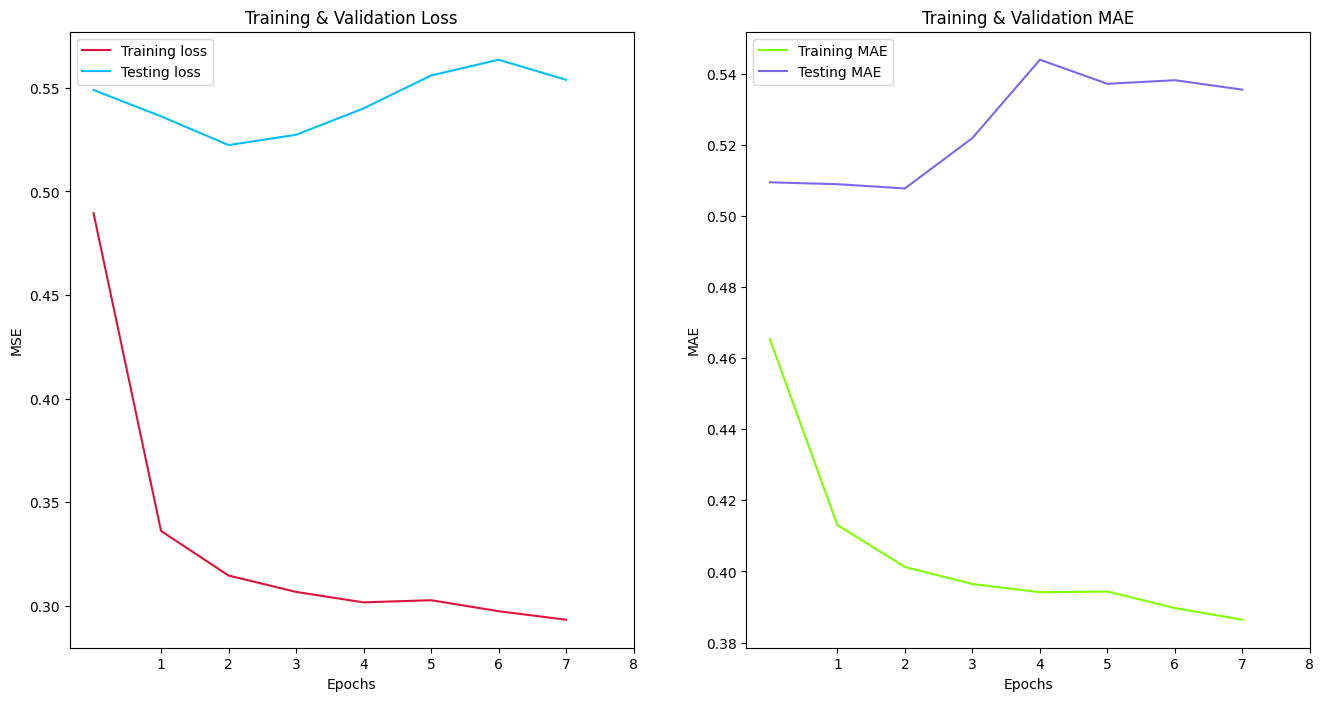

In [111]:
plt.figure(figsize=(16, 8))
# loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', color='crimson')
plt.plot(history.history['val_loss'], label='Testing loss', color='deepskyblue')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.xticks(range(1, len(history.history['loss']) + 1)) # set to int for each epoch
plt.ylabel('MSE')
plt.legend()

# mae
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', color='chartreuse')
plt.plot(history.history['val_mae'], label='Testing MAE', color='mediumslateblue')
plt.title('Training & Validation MAE')
plt.xlabel('Epochs')
plt.xticks(range(1, len(history.history['mae']) + 1))
plt.ylabel('MAE')
plt.legend();

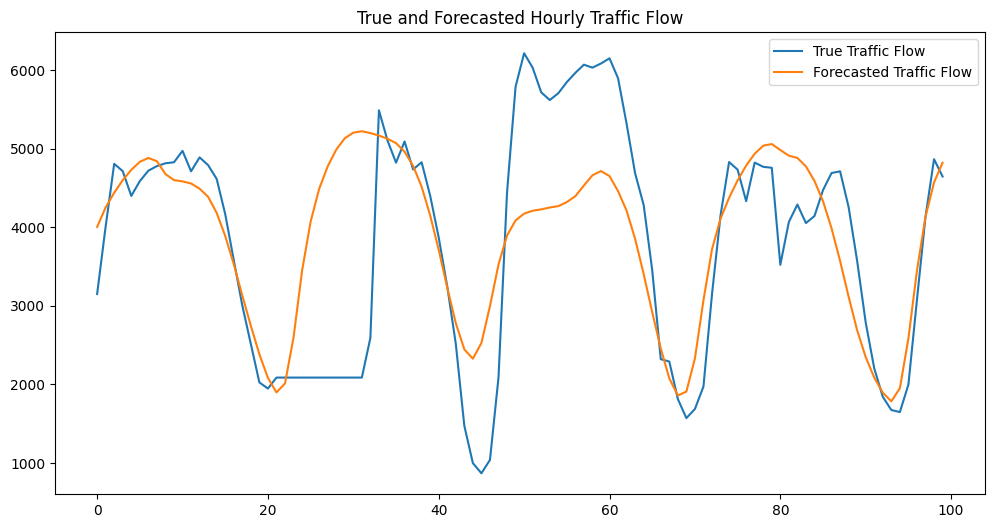

In [113]:
plt.figure(figsize=(12, 6))
plt.plot(true_traffic[:100, 1], label='True Traffic Flow')
plt.plot(predicted_traffic[:100, 1], label='Forecasted Traffic Flow')
plt.legend()
plt.title('True and Forecasted Hourly Traffic Flow')
plt.show()

### 4.5 Evaluation

| Time Granularity | Baseline RMSE | Baseline MAE | VAR RMSE | VAR MAE | Prophet RMSE | Prophet MAE | LSTM RMSE | LSTM MAE |
|------------------|---------------|--------------|----------|---------|--------------|-------------|-----------|----------|
| Monthly          | 3966.27       | 3428.63      | 510.44   | 424.80  | 2092.87      | 1666.75     | NA        | NA       |
| Weekly           | 3966.27       | 3428.63      | 518.11   | 421.54  | 497.31       | 418.09      | 766.69    | 701.04   |
| Daily            | 3966.27       | 3428.63      | 628.56   | 410.73  | 564.88       | 499.32      | 685.79    | 511.25   |
| Hourly           | 3966.27       | 3428.63      | 2081.83  | 1772.04 | 601.04       | 432.05      | 1618.27   | 1228.21  |


The table above provides a comparison of the RMSE and MAE values for different time granularities: Monthly, Weekly, Daily, and Hourly. These time granularities are essential for traffic forecasting as they represent different levels of resolution in predicting traffic patterns.

**Baseline**
* The baseline model is a naive forecast that uses the last value from the training set and continues it into the future.
* This simple assumption leads to high RMSE and MAE values across all granularities, indicating poor forecasting performance.

**VAR**
* The VAR model performs better than the Baseline model, particularly for monthly and weekly forecasts.
* VAR performed poorly for hourly granularities.
* VAR model is effective for capturing longer-term trends and relationships between multiple variables in traffic data.
* VAR struggles with high-frequency forecasting (in this study: hourly traffic flow), where traffic can be highly volatile due to factors such as accidents, road closures, or other sudden events.

**Prophet**
* The Prophet model shows strong performance at monthly and weekly granularities, similar to the VAR model. However, it also starts to lose accuracy as the time granularity becomes finer, particularly for daily and hourly traffic flow forecasts.
* It performs especially well at weekly forecasts, capturing the cyclical nature of traffic patterns, which can be influenced by workweek schedules, holidays, and weather conditions.
* While Prophet can model seasonality and holidays, it struggles when forecasting very high-frequency data (hourly), where short-term fluctuations and events (such as accidents) may be more significant.

**LSTM**
* It performs well at daily and weekly granularities but struggles at hourly forecasting, likely due to the complex and noisy nature of traffic flow at hourly frequency.
* The model may overfit to short-term noise, which leads to poor performance for hourly forecasts.
* It performs well at daily and weekly granularities, capturing daily traffic fluctuations and weekly patterns(peak hours, weekends).

## 5. Conclusion and Recommendations

| **Model**  | **Best Granularity** | **RMSE** (Best) | **MAE** (Best) | **Worst Granularity** | **RMSE** (Worst) | **MAE** (Worst) |
|------------|----------------------|-----------------|----------------|-----------------------|------------------|-----------------|
| **Baseline** | All                  | 3966.27         | 3428.63        | All                   | 3966.27          | 3428.63         |
| **VAR**     | Monthly/Weekly       | 510.44          | 424.80         | Hourly                | 2081.83          | 1772.04         |
| **Prophet** | Weekly               | 497.31          | 418.09         | Hourly                | 601.04           | 432.05          |
| **LSTM**    | Daily/Weekly         | 685.79          | 511.25         | Hourly                | 1618.27          | 1228.21         |


* The VAR model is effective for monthly and weekly forecasting but struggles with hourly forecasting, where traffic flow is more volatile and subject to external influences (accidents or road closures).
* The Prophet model performs well for weekly forecast and handles seasonality in traffic flow well, but fails to capture short-term traffic fluctuations effectively with hourly data. Compare to VAR and LSTM, prophet performs better with the hourly traffic data.
* The LSTM model shows good performance for daily forecasts. However, it struggles with hourly forecasts, likely due to the high variability in traffic flow at such fine resolutions.

| **Model**    | **Suitable Granularity** |
|--------------|----------------------|
| **VAR**      | Monthly/Weekly       |
| **Prophet**  | Weekly               |
| **LSTM**     | Daily/Weekly         |

* For monthly forecast, use VAR.
* For weekly and daily forecast, Prophet is suitable model. 

**Future improvements:**

There are some future steps to take this study to the next level.

* Model Tuning and Optimization
    * For LSTM, experiment with different hyperparameters: the number of layers, neurons, learning rates, and batch sizes.
    * For Prophet, experiment with different seasonalities, changepoint.
    * Consider using ensemble models that combine different approaches (VAR + LSTM) to leverage the strengths of each model at different granularities.

* Data Enrichment
    * Traffic events and incidents: Use historical incident data as features to improve model predictions, especially for hourly and daily data.

* Spatial Data Integration
    * Use spatial information with spatial-temporal models like spatiotemporal LSTM to capture both spatial and temporal dependencies in the data.